## Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.decomposition import PCA

## Loading data

##### CSV file encoding check

In [2]:
with open('../data/test.csv') as f:
    print(f)

with open('../data/train.csv') as f:
    print(f)

<_io.TextIOWrapper name='../data/test.csv' mode='r' encoding='cp1250'>
<_io.TextIOWrapper name='../data/train.csv' mode='r' encoding='cp1250'>


##### CSV file loading

In [3]:
df = pd.read_csv('../data/train.csv', encoding='cp1250')
df_pred = pd.read_csv('../data/test.csv', encoding='cp1250')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.head(6)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q


In [4]:
df.shape

(891, 12)

In [5]:
df_pred.head(6)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S


In [6]:
df_pred.shape

(418, 11)

In [7]:
X = df.drop(['Survived'], axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##### NOTE: *I do not create a single dataset from the training and testing files to prevent data leakage due to future encoding. Same reason for early train test split.*

## Data cleaning

##### 1.Duplicates.

In [8]:
df_full = pd.concat([df, df_pred], axis=0, ignore_index=True)

In [9]:
df_full[df_full.duplicated(subset=['Name'], keep=False)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
289,290,1.0,3,"Connolly, Miss. Kate",female,22.0,0,0,370373,7.7500,NaN,Q
696,697,0.0,3,"Kelly, Mr. James",male,44.0,0,0,363592,8.0500,NaN,S
891,892,NaN,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
897,898,NaN,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q


In [10]:
num_duplicates = df_full.duplicated(keep='first').sum()
num_duplicates

0

##### SUMMARY: *There aren't any duplicates. People with the same name and surname are coincidental.*

##### 2.Handling NaN, None, Null.

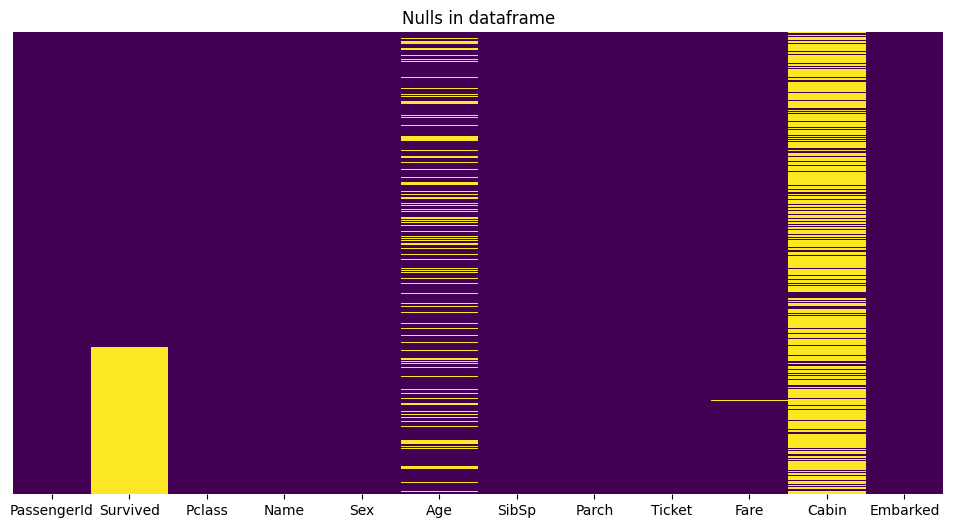

In [11]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_full.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Nulls in dataframe')
plt.savefig('../images/isnull.png', dpi=300, bbox_inches='tight')
plt.show()

##### NOTE: *Part of column "Survived" has to be empty for testing. Column "Age" I will imput with median. Column "Cabin" has too many missing values. I decide to convert it into HasCabin (0/1).*

In [12]:
age_imputer = SimpleImputer(strategy='median')
X_train['Age'] = age_imputer.fit_transform(X_train[['Age']])
X_test['Age'] = age_imputer.transform(X_test[['Age']])
df_pred['Age'] = age_imputer.transform(df_pred[['Age']])

X_train['HasCabin'] = X_train['Cabin'].notna().astype(int)
X_test['HasCabin'] = X_test['Cabin'].notna().astype(int)
df_pred['HasCabin'] = df_pred['Cabin'].notna().astype(int)

X_train.head(6)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
692,693,3,"Lam, Mr. Ali",male,28.5,0,0,1601,56.4958,NaN,S,0
481,482,2,"Frost, Mr. Anthony Wood ""Archie""",male,28.5,0,0,239854,0.0000,NaN,S,0
527,528,1,"Farthing, Mr. John",male,28.5,0,0,PC 17483,221.7792,C95,S,1
855,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S,0
801,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S,0
652,653,3,"Kalvik, Mr. Johannes Halvorsen",male,21.0,0,0,8475,8.4333,NaN,S,0


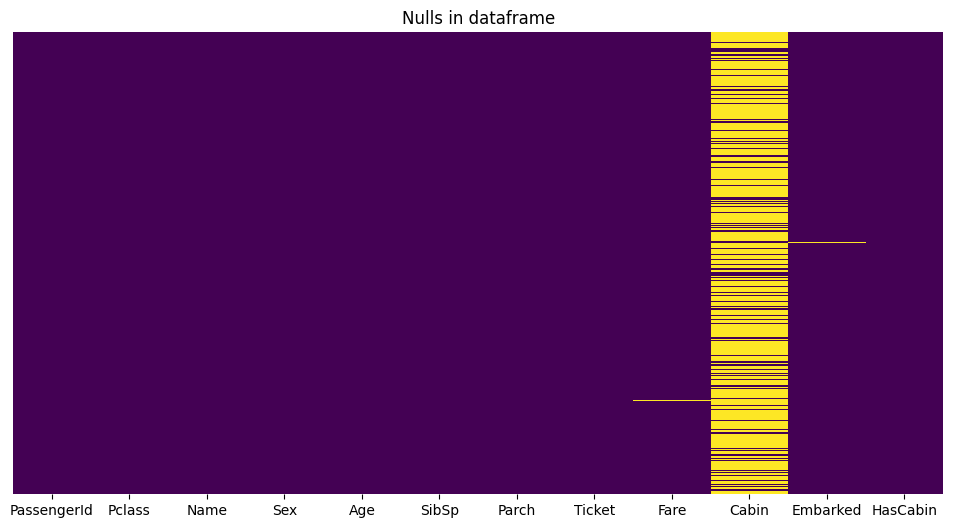

In [13]:
df_full = pd.concat([X_train, X_test, df_pred], axis=0, ignore_index=True)

plt.figure(figsize=(12, 6))
sns.heatmap(df_full.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Nulls in dataframe')
plt.savefig('../images/isnull_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

##### NOTE: *Column "Cabin" I will delete later.*

##### 3.Changing columns names.

In [14]:
X_train.head(1)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
692,693,3,"Lam, Mr. Ali",male,28.5,0,0,1601,56.4958,NaN,S,0


In [15]:
for df in [X_test, X_train, df_pred]:
    df.rename(columns={'PassengerId': 'Id', 'Pclass': 'Class', 'SibSp': 'Siblings_Spouses', 'Parch': 'Parents_Childs'}, inplace=True)
X_train.head(1)

,Id,Class,Name,Sex,Age,Siblings_Spouses,Parents_Childs,Ticket,Fare,Cabin,Embarked,HasCabin
692,693,3,"Lam, Mr. Ali",male,28.5,0,0,1601,56.4958,NaN,S,0


##### 4.Adding columns.

In [16]:
for df in [X_test, X_train, df_pred]:
    df['FamilySize'] = 1 + df['Siblings_Spouses'] + df['Parents_Childs']
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
X_train.head(5)

,Id,Class,Name,Sex,Age,Siblings_Spouses,Parents_Childs,Ticket,Fare,Cabin,Embarked,HasCabin,FamilySize,Title
692,693,3,"Lam, Mr. Ali",male,28.5,0,0,1601,56.4958,NaN,S,0,1,Mr
481,482,2,"Frost, Mr. Anthony Wood ""Archie""",male,28.5,0,0,239854,0.0000,NaN,S,0,1,Mr
527,528,1,"Farthing, Mr. John",male,28.5,0,0,PC 17483,221.7792,C95,S,1,1,Mr
855,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S,0,2,Mrs
801,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S,0,3,Mrs


##### 5.Removing unnecessary columns.

In [17]:
df_full['Ticket'].value_counts(10)

Ticket
CA. 2343              11
1601                   8
CA 2144                8
347077                 7
PC 17608               7
3101295                7
347082                 7
S.O.C. 14879           7
382652                 6
113781                 6
347088                 6
19950                  6
4133                   5
349909                 5
W./C. 6608             5
113503                 5
220845                 5
16966                  5
PC 17757               5
113760                 4
230136                 4
W./C. 6607             4
C.A. 34651             4
12749                  4
17421                  4
SC/Paris 2123          4
C.A. 33112             4
LINE                   4
PC 17760               4
36928                  4
2666                   4
PC 17755               4
24160                  4
PC 17483               4
C.A. 2315              4
PC 17761               3
2678                   3
315153                 3
248727                 3
345773            

In [18]:
for df in [X_test, X_train]:
    df.drop(columns=['Id', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

for df in [df_pred]:
    df.drop(columns=['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
    
X_train.head(1)

,Class,Sex,Age,Siblings_Spouses,Parents_Childs,Fare,Embarked,HasCabin,FamilySize,Title
692,3,male,28.5,0,0,56.4958,S,0,1,Mr


##### SUMMARY: *I could extract from "Ticket" for example prefix, but I decided to delete it, due to many unique values.*

##### 6.Fixing columns data types. Encoding categorical variables.

In [19]:
X_train.dtypes

Class                 int64
Sex                  object
Age                 float64
Siblings_Spouses      int64
Parents_Childs        int64
Fare                float64
Embarked             object
HasCabin              int32
FamilySize            int64
Title                object
dtype: object

In [20]:
for df in [X_test, X_train, df_pred]:
    columns = ['Age', 'HasCabin']
    for col in columns:
        df[col] = df[col].astype('int64')

X_train.dtypes

Class                 int64
Sex                  object
Age                   int64
Siblings_Spouses      int64
Parents_Childs        int64
Fare                float64
Embarked             object
HasCabin              int64
FamilySize            int64
Title                object
dtype: object

In [21]:
X_train.head()

,Class,Sex,Age,Siblings_Spouses,Parents_Childs,Fare,Embarked,HasCabin,FamilySize,Title
692,3,male,28,0,0,56.4958,S,0,1,Mr
481,2,male,28,0,0,0.0000,S,0,1,Mr
527,1,male,28,0,0,221.7792,S,1,1,Mr
855,3,female,18,0,1,9.3500,S,0,2,Mrs
801,2,female,31,1,1,26.2500,S,0,3,Mrs


In [22]:
df_full['Embarked'].isnull().sum()

2

In [23]:
df_full['Embarked'].value_counts()

Embarked
S    914
C    270
Q    123
Name: count, dtype: int64

In [24]:
for df in [X_test, X_train, df_pred]:
    df['Embarked'] = df['Embarked'].fillna(value='S')

##### NOTE: *I have replaced missing two values in column "Embarked" with most popular "S".*

In [25]:
df_full['Fare'].isnull().sum()

1

In [26]:
for df in [X_test, X_train, df_pred]:
    df['Fare'] = df.groupby('Class')['Fare'].transform(lambda x: x.fillna(x.median()))

In [27]:
for df in [X_test, X_train, df_pred]:
    print(df['Title'].unique())

['Mr' 'Miss' 'Mrs' 'Major' 'Mme' 'Master' 'Capt' 'Countess' 'Dr' 'Rev']
['Mr' 'Mrs' 'Col' 'Miss' 'Rev' 'Major' 'Master' 'Dr' 'Mlle' 'Lady' 'Sir'
 'Ms' 'Jonkheer' 'Don']
['Mr' 'Mrs' 'Miss' 'Master' 'Ms' 'Col' 'Rev' 'Dr' 'Dona']


In [28]:
for df in [X_test, X_train, df_pred]:
    df['Title'] = df['Title'].replace(['Master', 'Don', 'Rev', 'Dr', 'Major', 'Col', 'Sir', 'Capt', 'Countess', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Lady', 'Ms')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')

for df in [X_test, X_train, df_pred]:
    print(df['Title'].unique())

['Mr' 'Miss' 'Mrs' 'Rare']
['Mr' 'Mrs' 'Rare' 'Miss' 'Ms']
['Mr' 'Mrs' 'Miss' 'Rare' 'Ms']


In [29]:
columns = ['Title', 'Sex', 'Embarked']
encoders = {}
for column in columns:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
    encoded = encoder.fit_transform(X_train[[column]])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out([column]), index=X_train.index)
    X_train = pd.concat([X_train.drop(column, axis=1), encoded_df], axis=1)
    encoders[column] = encoder
    
for dataset in [X_test, df_pred]:
    for column in columns:
        encoder = encoders[column]
        encoded = encoder.transform(dataset[[column]])
        encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out([column]), index=dataset.index)
        dataset.drop(column, axis=1, inplace=True)
        dataset[encoded_df.columns] = encoded_df

In [30]:
X_train.head()

,Class,Age,Siblings_Spouses,Parents_Childs,Fare,HasCabin,FamilySize,Title_Miss,Title_Mr,Title_Mrs,Title_Ms,Title_Rare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
692,3,28,0,0,56.4958,0,1,0,1,0,0,0,0,1,0,0,1
481,2,28,0,0,0.0000,0,1,0,1,0,0,0,0,1,0,0,1
527,1,28,0,0,221.7792,1,1,0,1,0,0,0,0,1,0,0,1
855,3,18,0,1,9.3500,0,2,0,0,1,0,0,1,0,0,0,1
801,2,31,1,1,26.2500,0,3,0,0,1,0,0,1,0,0,0,1


##### 7.Checking if there are negative intigers/floats.

In [31]:
X_train.dtypes

Class                 int64
Age                   int64
Siblings_Spouses      int64
Parents_Childs        int64
Fare                float64
HasCabin              int64
FamilySize            int64
Title_Miss            int32
Title_Mr              int32
Title_Mrs             int32
Title_Ms              int32
Title_Rare            int32
Sex_female            int32
Sex_male              int32
Embarked_C            int32
Embarked_Q            int32
Embarked_S            int32
dtype: object

In [32]:
columns = [0, 1, 4]
for df in [X_test, X_train, df_pred]:
    for col in columns:
        negatives = (df.iloc[:,col]< 0).any()
        print(negatives)

False
False
False
False
False
False
False
False
False


##### SUMMARY: *There aren't any negative values.*

## EDA - Exploratory Data Analysis

In [33]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Class             712 non-null    int64  
 1   Age               712 non-null    int64  
 2   Siblings_Spouses  712 non-null    int64  
 3   Parents_Childs    712 non-null    int64  
 4   Fare              712 non-null    float64
 5   HasCabin          712 non-null    int64  
 6   FamilySize        712 non-null    int64  
 7   Title_Miss        712 non-null    int32  
 8   Title_Mr          712 non-null    int32  
 9   Title_Mrs         712 non-null    int32  
 10  Title_Ms          712 non-null    int32  
 11  Title_Rare        712 non-null    int32  
 12  Sex_female        712 non-null    int32  
 13  Sex_male          712 non-null    int32  
 14  Embarked_C        712 non-null    int32  
 15  Embarked_Q        712 non-null    int32  
 16  Embarked_S        712 non-null    int32  
dtype

In [34]:
X_train.describe().map(lambda x: f'{x:0.2f}')

,Class,Age,Siblings_Spouses,Parents_Childs,Fare,HasCabin,FamilySize,Title_Miss,Title_Mr,Title_Mrs,Title_Ms,Title_Rare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
count,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00
mean,2.31,29.44,0.49,0.39,31.82,0.22,1.88,0.20,0.58,0.15,0.00,0.07,0.36,0.64,0.20,0.08,0.73
std,0.83,13.04,1.06,0.84,48.06,0.42,1.59,0.40,0.49,0.36,0.05,0.25,0.48,0.48,0.40,0.27,0.45
min,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2.00,22.00,0.00,0.00,7.90,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,3.00,28.00,0.00,0.00,14.45,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
75%,3.00,36.00,1.00,0.00,31.00,0.00,2.00,0.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00
max,3.00,80.00,8.00,6.00,512.33,1.00,11.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [35]:
X_train.select_dtypes(include=['int64', 'float64']).columns

Index(['Class', 'Age', 'Siblings_Spouses', 'Parents_Childs', 'Fare',
       'HasCabin', 'FamilySize'],
      dtype='object')

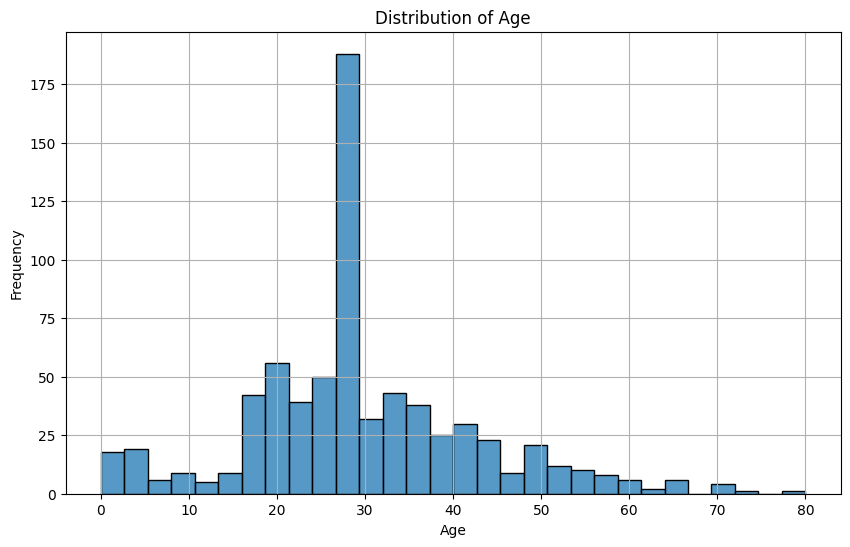

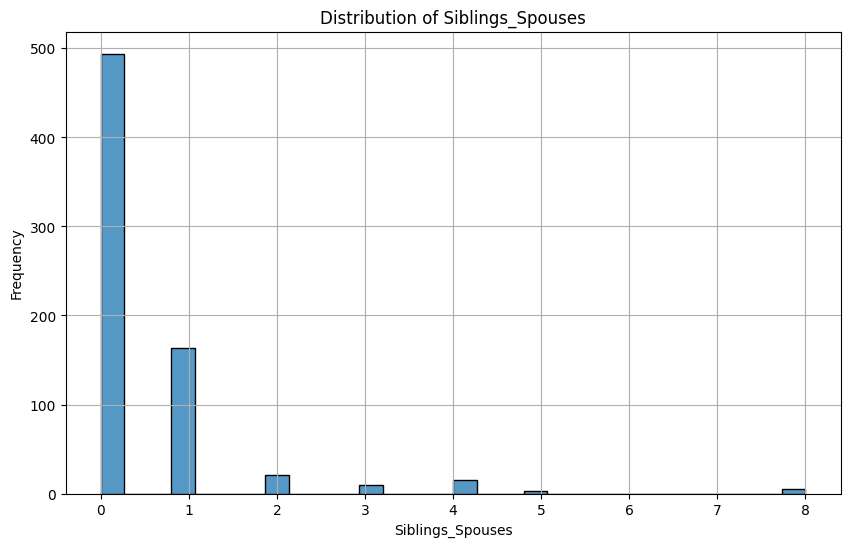

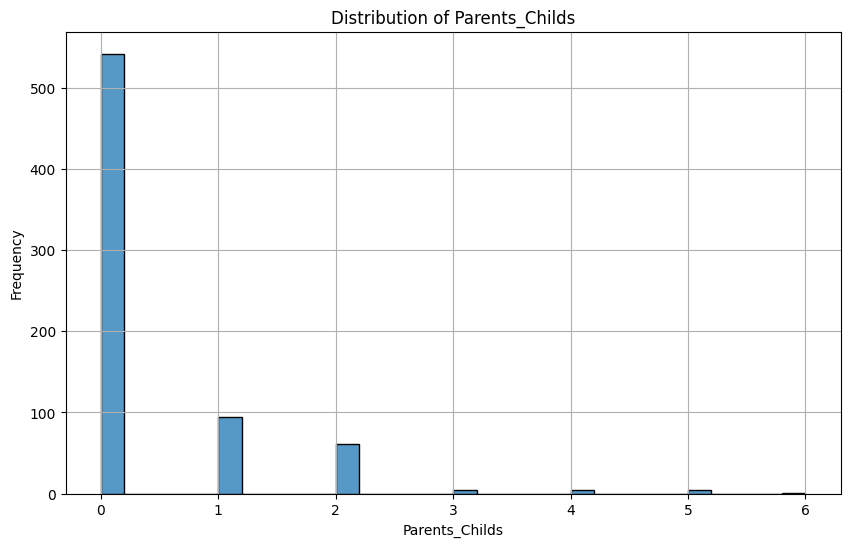

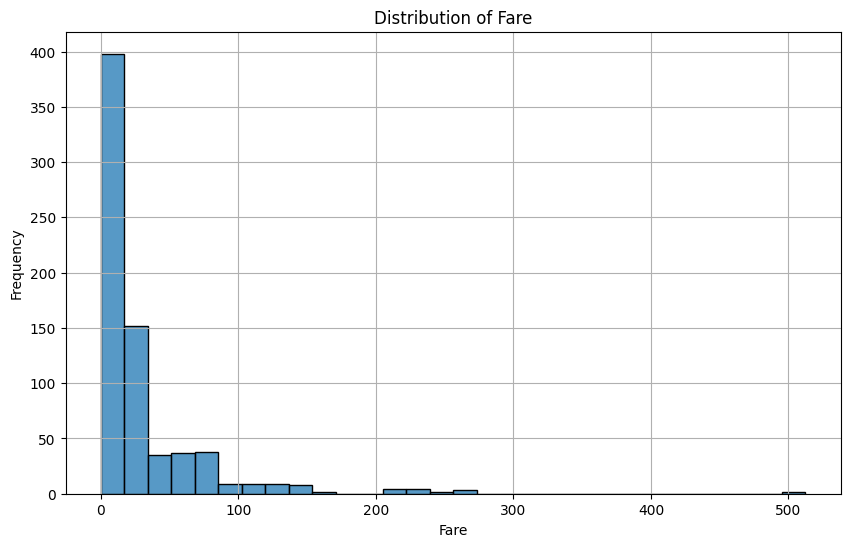

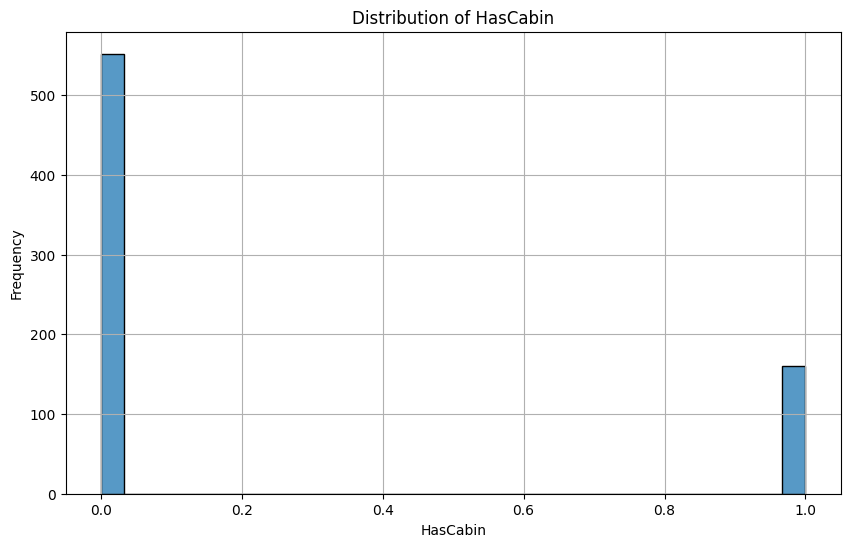

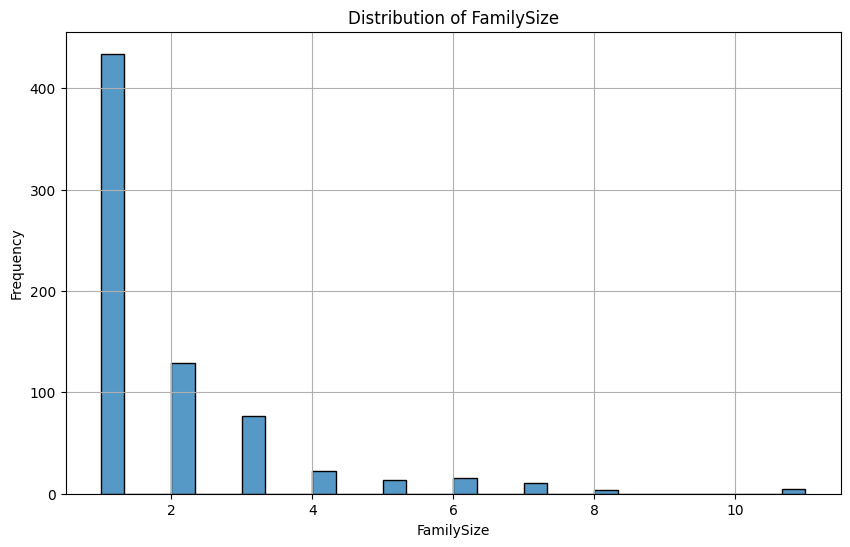

In [36]:
cols = ['Age', 'Siblings_Spouses', 'Parents_Childs', 'Fare', 'HasCabin', 'FamilySize']
for col in cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(X_train[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.savefig(f'../images/{col}_histogram.png', dpi=300, bbox_inches='tight')
    plt.show()

##### NOTE: *I will try to make log(Fare +1) to see outcome. "Age" may stay as it is and rest are discrete.*

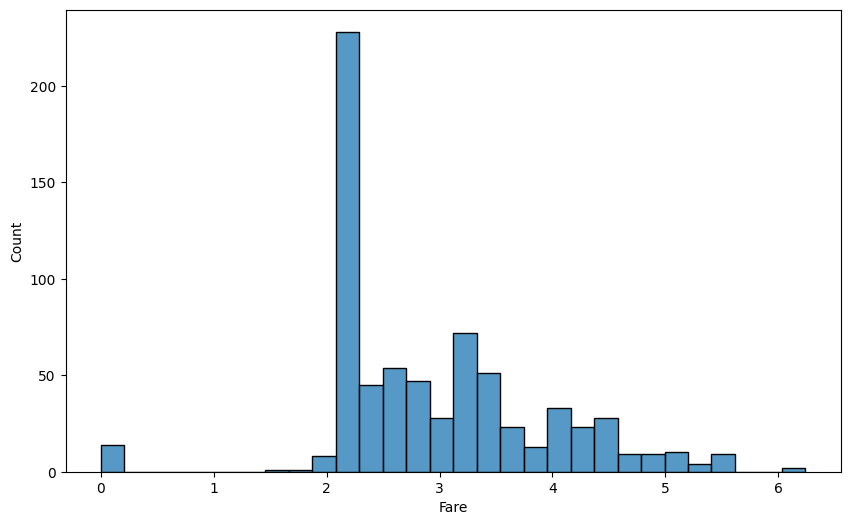

In [37]:
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(X_train['Fare']), bins=30)
plt.savefig('../images/log1p_fare_hist.png', dpi=300, bbox_inches='tight')
plt.show()

##### NOTE:*The distribution is still not satisfying. I decide to make quantiles and divide the set into three.*

In [38]:
X_train['Fare_Bins'], bins = pd.qcut(X_train['Fare'], q=3, labels=[0, 1, 2], retbins=True)
X_train.drop(columns=['Fare'], inplace=True)

for df in [X_test, df_pred]:
    df['Fare_Bins'] = pd.cut(df['Fare'], bins=bins, labels=[0, 1, 2], include_lowest=True)
    df.drop(columns=['Fare'], inplace=True)

In [39]:
for df in [X_train, X_test, df_pred]:
    print(df['Fare_Bins'].value_counts())

Fare_Bins
1    242
0    237
2    233
Name: count, dtype: int64
Fare_Bins
2    62
1    60
0    57
Name: count, dtype: int64
Fare_Bins
1    148
0    139
2    131
Name: count, dtype: int64


In [40]:
X_train['Fare_Bins'] = X_train['Fare_Bins'].astype(int)
for df in [X_test, df_pred]:
    df['Fare_Bins'] = df['Fare_Bins'].astype(int)

In [41]:
X_train.head()

,Class,Age,Siblings_Spouses,Parents_Childs,HasCabin,FamilySize,Title_Miss,Title_Mr,Title_Mrs,Title_Ms,Title_Rare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Fare_Bins
692,3,28,0,0,0,1,0,1,0,0,0,0,1,0,0,1,2
481,2,28,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0
527,1,28,0,0,1,1,0,1,0,0,0,0,1,0,0,1,2
855,3,18,0,1,0,2,0,0,1,0,0,1,0,0,0,1,1
801,2,31,1,1,0,3,0,0,1,0,0,1,0,0,0,1,2


In [42]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
encoded = encoder.fit_transform(X_train[['Fare_Bins']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Fare_Bins']), index=X_train.index)
X_train = pd.concat([X_train.drop('Fare_Bins', axis=1), encoded_df], axis=1)
    
for dataset in [X_test, df_pred]:
    encoded = encoder.transform(dataset[['Fare_Bins']])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Fare_Bins']), index=dataset.index)
    dataset.drop('Fare_Bins', axis=1, inplace=True)
    dataset[encoded_df.columns] = encoded_df

X_train.head(1)

,Class,Age,Siblings_Spouses,Parents_Childs,HasCabin,FamilySize,Title_Miss,Title_Mr,Title_Mrs,Title_Ms,Title_Rare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Fare_Bins_0,Fare_Bins_1,Fare_Bins_2
692,3,28,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1


In [43]:
X_train.dtypes

Class               int64
Age                 int64
Siblings_Spouses    int64
Parents_Childs      int64
HasCabin            int64
FamilySize          int64
Title_Miss          int32
Title_Mr            int32
Title_Mrs           int32
Title_Ms            int32
Title_Rare          int32
Sex_female          int32
Sex_male            int32
Embarked_C          int32
Embarked_Q          int32
Embarked_S          int32
Fare_Bins_0         int32
Fare_Bins_1         int32
Fare_Bins_2         int32
dtype: object

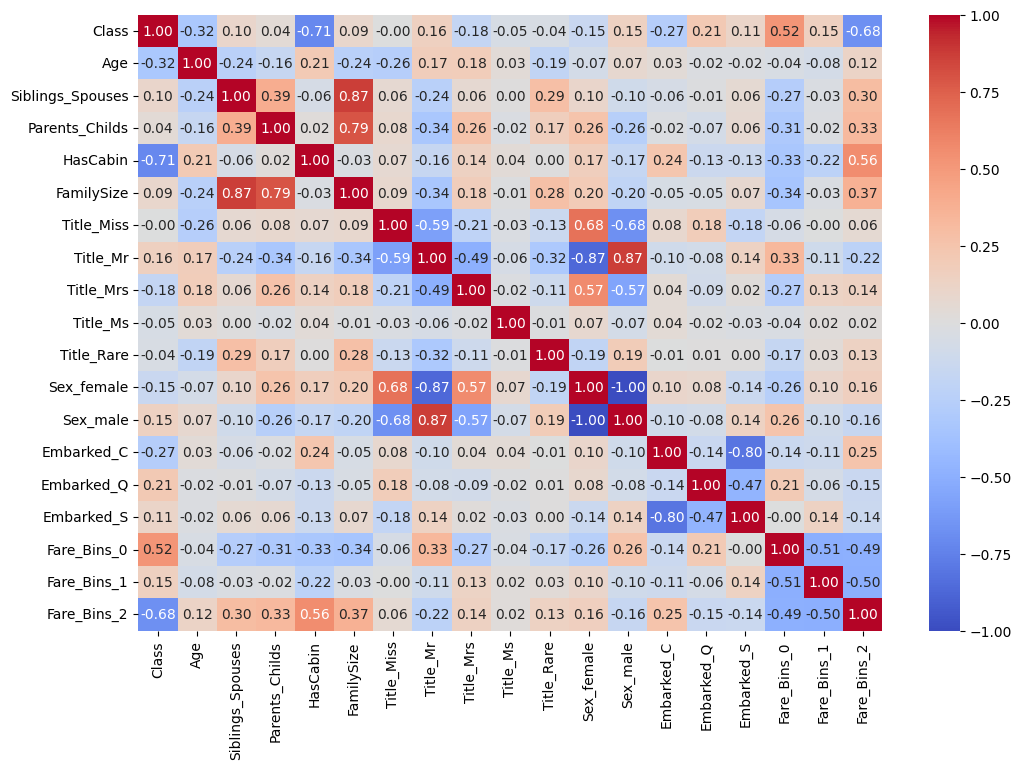

In [44]:
plt.figure(figsize=(12,8))
sns.heatmap(X_train.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.savefig('../images/corr_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

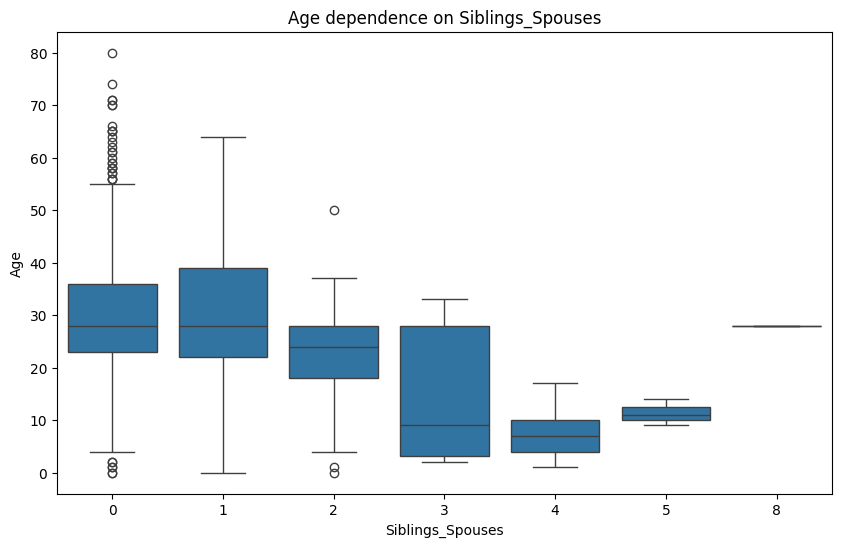

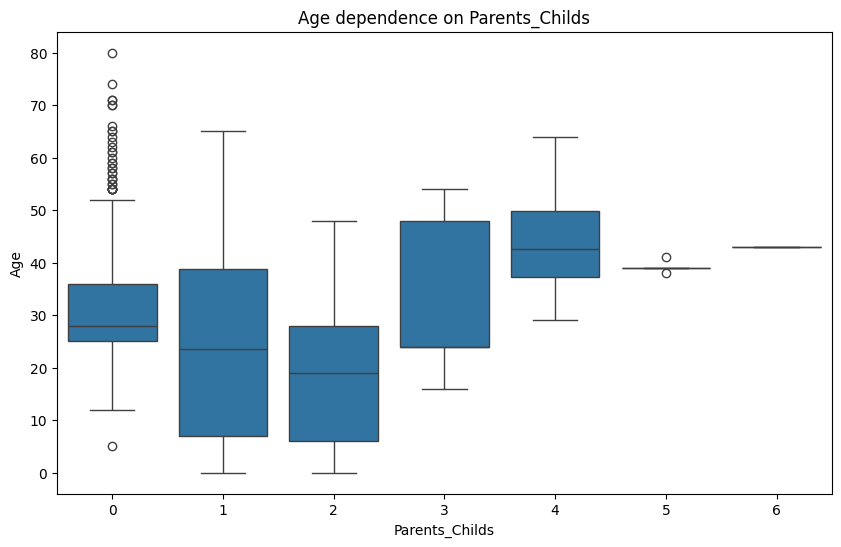

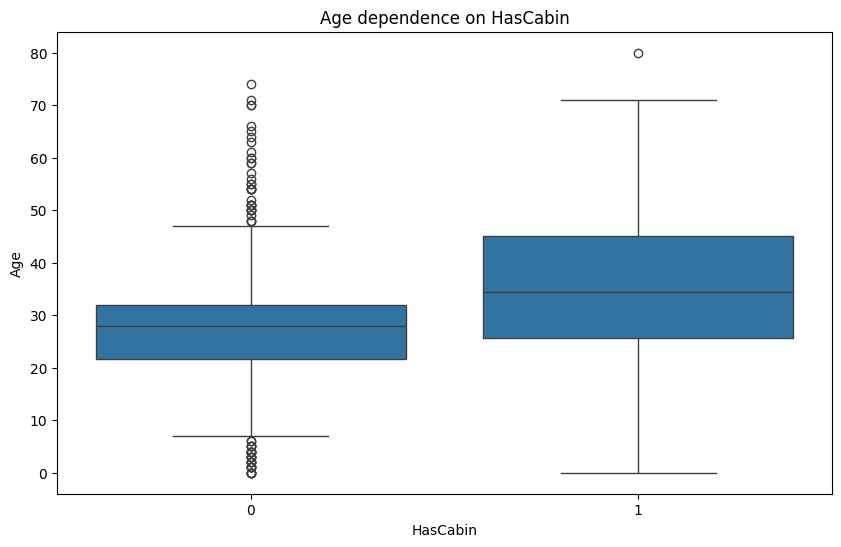

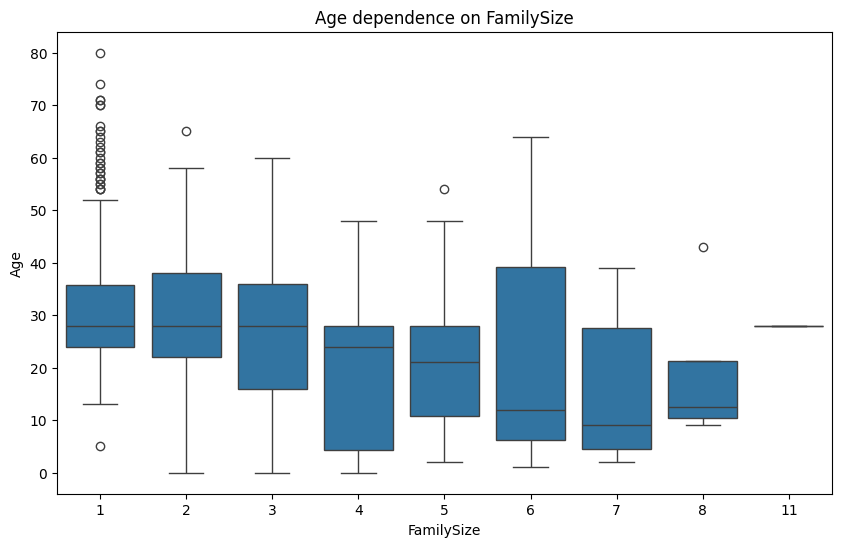

In [45]:
cols = ['Siblings_Spouses', 'Parents_Childs', 'HasCabin', 'FamilySize']
for col in cols:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=X_train[col], y=X_train['Age'])
    plt.title(f"Age dependence on {col}")
    plt.savefig(f'../images/{col}_box.png', dpi=300, bbox_inches='tight')
    plt.show()

## Creating and training basic models. Metrics

Models Creation

In [46]:
models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(random_state=42, max_iter=1000)),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier()),
    'XGB': XGBClassifier(random_state=42),
    'SVC': make_pipeline(StandardScaler(), SVC(probability=True, random_state=42))
}

##### Models Training and Metrics

In [47]:
y_test.value_counts(normalize=True)


Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64

In [48]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    print(f'\n{name}:')
    print('Accuracy:  {:0.2f}'.format(accuracy_score(y_test, y_pred)))
    print('Precision: {:0.2f}'.format(precision_score(y_test, y_pred)))
    print('Recall:   {:0.2f}'.format(recall_score(y_test, y_pred)))
    print('Roc Auc: {:0.2f}'.format(roc_auc_score(y_test, y_pred)))
    print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
    
for name, model in models.items():
    model.fit(X_train, y_train)
    joblib.dump(model, f"..\models\{name.lower().replace(' ', '_')}.pkl")
    evaluate_model(model, X_test, y_test, name)


Logistic Regression:
Accuracy:  0.82
Precision: 0.78
Recall:   0.72
Roc Auc: 0.80
Confusion Matrix:
 [[96 14]
 [19 50]]

Random Forest:
Accuracy:  0.80
Precision: 0.74
Recall:   0.74
Roc Auc: 0.79
Confusion Matrix:
 [[92 18]
 [18 51]]

KNN:
Accuracy:  0.81
Precision: 0.77
Recall:   0.72
Roc Auc: 0.79
Confusion Matrix:
 [[95 15]
 [19 50]]

XGB:
Accuracy:  0.81
Precision: 0.78
Recall:   0.71
Roc Auc: 0.79
Confusion Matrix:
 [[96 14]
 [20 49]]

SVC:
Accuracy:  0.82
Precision: 0.79
Recall:   0.72
Roc Auc: 0.80
Confusion Matrix:
 [[97 13]
 [19 50]]


## Feature Selection/Extraction and New Models

##### Models Creation

In [ ]:
n_features_to_select = 8
lr_rfe = RFE(estimator=LogisticRegression(), n_features_to_select=n_features_to_select)
rf_sfm = SelectFromModel(estimator=RandomForestClassifier(random_state=42), max_features=n_features_to_select)
knn_pca = PCA(n_components=n_features_to_select)
xgb_sfm = SelectFromModel(estimator=XGBClassifier(random_state=42), max_features=n_features_to_select)
svc_pca = PCA(n_components=n_features_to_select)

models_fs = {
    'Logistic Regression RFE': make_pipeline(StandardScaler(), lr_rfe, LogisticRegression(random_state=42, max_iter=1000)),
    'Random Forest SFM': make_pipeline(rf_sfm, RandomForestClassifier(random_state=42)),
    'KNN PCA': make_pipeline(StandardScaler(), knn_pca, KNeighborsClassifier()),
    'XGB SFM': make_pipeline(xgb_sfm, XGBClassifier(random_state=42)),
    'SVC PCA': make_pipeline(StandardScaler(), svc_pca, SVC(probability=True, random_state=42))
}

##### Models Training and Metrics

In [50]:
results = []

for name, model in models_fs.items():
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'roc_auc'],
        return_train_score=False,
        return_estimator=True
    )
    
    for i in range(5):
        results.append({
            'Model': name,
            'Fold': i + 1,
            'Accuracy': cv_results['test_accuracy'][i],
            'Precision': cv_results['test_precision'][i],
            'Recall': cv_results['test_recall'][i],
            'ROC AUC': cv_results['test_roc_auc'][i]
        })
    recalls = cv_results['test_recall']
    estimators = cv_results['estimator']
    
    best_idx = np.argmax(recalls)
    best_recall = recalls[best_idx]
    best_model = estimators[best_idx]
    
    print(f'Best recall metric for {name}: {best_recall:.3f} at fold {best_idx+1}')
    joblib.dump(best_model, f"..\models\{name.lower().replace(' ', '_')}.pkl")
    
cv_df = pd.DataFrame(results)
cv_df

Best recall metric for Logistic Regression RFE: 0.800 at fold 1
Best recall metric for Random Forest SFM: 0.778 at fold 4
Best recall metric for KNN PCA: 0.818 at fold 3
Best recall metric for XGB SFM: 0.745 at fold 1
Best recall metric for SVC PCA: 0.800 at fold 3


,Model,Fold,Accuracy,Precision,Recall,ROC AUC
0,Logistic Regression RFE,1,0.825175,0.758621,0.800000,0.847417
1,Logistic Regression RFE,2,0.776224,0.734694,0.654545,0.867769
2,Logistic Regression RFE,3,0.845070,0.811321,0.781818,0.873668
3,Logistic Regression RFE,4,0.830986,0.777778,0.777778,0.878472
4,Logistic Regression RFE,5,0.816901,0.759259,0.759259,0.870581
5,Random Forest SFM,1,0.769231,0.720000,0.654545,0.813326
6,Random Forest SFM,2,0.769231,0.750000,0.600000,0.835331
7,Random Forest SFM,3,0.809859,0.769231,0.727273,0.867398
8,Random Forest SFM,4,0.845070,0.807692,0.777778,0.891730
9,Random Forest SFM,5,0.802817,0.740741,0.740741,0.821444


##### SUMMAR: *Considering human life I decided recall metric is most important and models with highest value I have choosen to save.*

## Hyperparameter Tuning and New Models

##### Models and Parameters Creation

In [51]:
pipe_lr = make_pipeline(StandardScaler(), RFE(estimator=LogisticRegression()), LogisticRegression(random_state=42, max_iter=1000))
pipe_rf = make_pipeline(SelectFromModel(estimator=RandomForestClassifier(random_state=42)), RandomForestClassifier(random_state=42))
pipe_knn = make_pipeline(StandardScaler(), PCA(), KNeighborsClassifier())
pipe_xgb = make_pipeline(SelectFromModel(estimator=XGBClassifier(random_state=42)), XGBClassifier(random_state=42))
pipe_svc = make_pipeline(StandardScaler(), PCA(), SVC(probability=True, random_state=42))

param_grid_lr = {
    'rfe__n_features_to_select': [6, 8, 11, 16, 19],
    'logisticregression__C': [0.1, 1.0, 10.0]
}

param_grid_rf = {
    'selectfrommodel__max_features': [6, 8, 11, 16, 19],
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [None, 5, 10, 20]
}

param_grid_knn = {
    'pca__n_components': [6, 8, 11, 16, 19],
    'kneighborsclassifier__n_neighbors': [3, 5, 7],
    'kneighborsclassifier__weights': ['uniform', 'distance']
}

param_grid_xgb = {
    'selectfrommodel__max_features': [6, 8, 11, 16, 19],
    'xgbclassifier__n_estimators': [50, 100],
    'xgbclassifier__max_depth': [3, 6],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.3]
}

param_grid_svc = {
    'pca__n_components': [6, 8, 11, 16, 19],
    'svc__C': [0.1, 1.0, 10.0],
    'svc__gamma': ['scale', 'auto'],
    'svc__kernel': ['rbf', 'linear']
}

models_params = {
    'Logistic Regression RFE CV': (pipe_lr, param_grid_lr),
    'Random Forest SFM CV': (pipe_rf, param_grid_rf),
    'KNN PCA CV': (pipe_knn, param_grid_knn),
    'XGBoost SFM CV': (pipe_xgb, param_grid_xgb),
    'SVC PCA CV': (pipe_svc, param_grid_svc)
}

##### Model Training and Metrics

In [52]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    print(f'\n{name}:')
    print('Accuracy:  {:0.2f}'.format(accuracy_score(y_test, y_pred)))
    print('Precision: {:0.2f}'.format(precision_score(y_test, y_pred)))
    print('Recall:   {:0.2f}'.format(recall_score(y_test, y_pred)))
    print('Roc Auc: {:0.2f}'.format(roc_auc_score(y_test, y_pred)))
    print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
    
best_models = {}

for name, (pipeline, param_grid) in models_params.items():
    grid = GridSearchCV(pipeline, param_grid=param_grid, cv=5, n_jobs=-1, verbose=0, scoring='recall')
    grid.fit(X_train, y_train)

    print(f"\nBest params for {name}: {grid.best_params_}")
    best_model = grid.best_estimator_

    joblib.dump(best_model, f"..\models\{name.lower().replace(' ', '_')}.pkl")
    evaluate_model(best_model, X_test, y_test, name)
    best_models[name] = best_model


Best params for Logistic Regression RFE CV: {'logisticregression__C': 1.0, 'rfe__n_features_to_select': 19}

Logistic Regression RFE CV:
Accuracy:  0.82
Precision: 0.78
Recall:   0.72
Roc Auc: 0.80
Confusion Matrix:
 [[96 14]
 [19 50]]

Best params for Random Forest SFM CV: {'randomforestclassifier__max_depth': 5, 'randomforestclassifier__n_estimators': 50, 'selectfrommodel__max_features': 8}

Random Forest SFM CV:
Accuracy:  0.79
Precision: 0.76
Recall:   0.65
Roc Auc: 0.76
Confusion Matrix:
 [[96 14]
 [24 45]]

Best params for KNN PCA CV: {'kneighborsclassifier__n_neighbors': 5, 'kneighborsclassifier__weights': 'uniform', 'pca__n_components': 16}

KNN PCA CV:
Accuracy:  0.80
Precision: 0.77
Recall:   0.71
Roc Auc: 0.79
Confusion Matrix:
 [[95 15]
 [20 49]]

Best params for XGBoost SFM CV: {'selectfrommodel__max_features': 6, 'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100}

XGBoost SFM CV:
Accuracy:  0.79
Precision: 0.76
Recall:

##### SUMMARY: *The use of feature selection/extraction and hyperparameter tuning does not significantly affect the performance of selected models and their metrics. This may be due to too few features.*

## Prediction

In [53]:
model = joblib.load('../models/svc_pca_cv.pkl')

y_pred = model.predict(df_pred.drop(['Id'], axis=1))

submission = pd.DataFrame({ 
    'PassengerId': df_pred['Id'],
    'Survived': y_pred.astype(int)
})

submission.to_csv('../results/submission.csv', index=False)